В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, f1_score

import warnings
warnings.filterwarnings("ignore")

print('Бібліотеки імпортовано')

Бібліотеки імпортовано


numeric_cols: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_cols: ['Geography', 'Gender']
train_inputs: (12000, 10) | val_inputs: (3000, 10)
Кількість ознак після препроцесингу: 13
Area under ROC score on Train dataset: 0.8824
F1 score on Train dataset: 0.6352


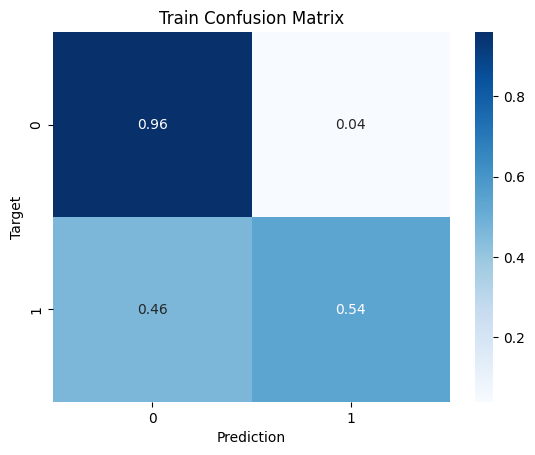

Area under ROC score on Validation dataset: 0.8797
F1 score on Validation dataset: 0.6412


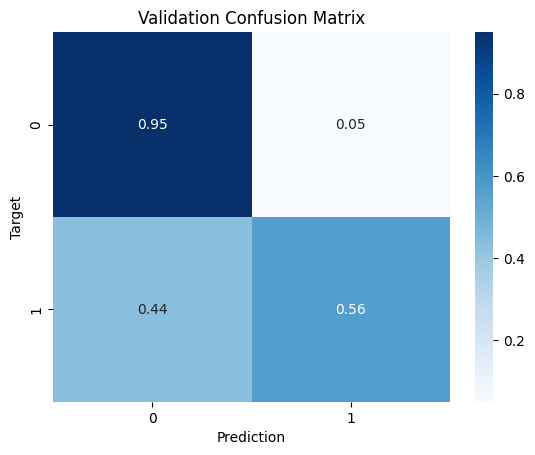

['log_reg_pipeline.joblib']

In [5]:
# Читання даних (поза пайплайном)
raw_df = pd.read_csv('train.csv', index_col=0)

# Розбиття на трен. і вал. набори (поза пайплайном)
train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42,
                                    stratify=raw_df.Exited)

# Створюємо трен. і вал. набори
input_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
              'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
              'EstimatedSalary']
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

print('numeric_cols:', numeric_cols)
print('categorical_cols:', categorical_cols)
print('train_inputs:', train_inputs.shape, '| val_inputs:', val_inputs.shape)

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Створюємо пайплайн: препроцесинг + модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

print('Кількість ознак після препроцесингу:',
      model_pipeline.named_steps['preprocessor'].transform(train_inputs).shape[1])

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]

    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.4f}")
    print(f"F1 score on {name} dataset: {f1_score(targets, preds, pos_label=1.0):.4f}")

    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'log_reg_pipeline.joblib')

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Кількість ознак після препроцесингу: 50

Area under ROC score on Train (degree=2) dataset: 0.9217
F1 score on Train (degree=2) dataset: 0.6971


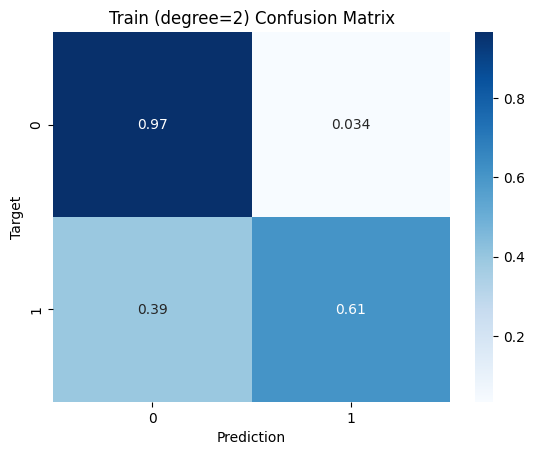

Area under ROC score on Validation (degree=2) dataset: 0.9191
F1 score on Validation (degree=2) dataset: 0.6924


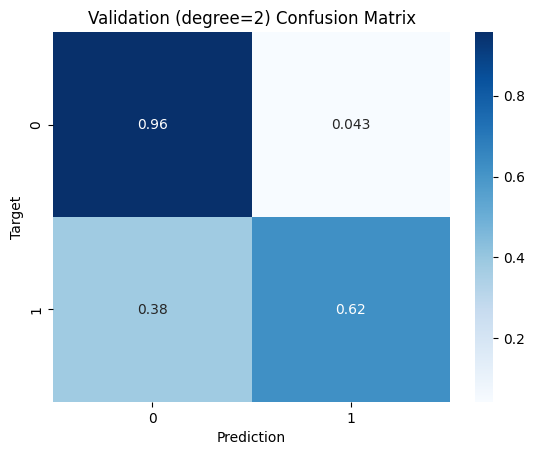

In [6]:
# Числовий трансформер з поліноміальними ознаками до степені 2
numeric_transformer_poly2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2))
])

preprocessor_poly2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly2, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_poly2 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly2),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_poly2.fit(train_inputs, train_targets)

print('Кількість ознак після препроцесингу:',
      model_pipeline_poly2.named_steps['preprocessor'].transform(train_inputs).shape[1])
print()
train_preds_poly2 = predict_and_plot(model_pipeline_poly2, train_inputs, train_targets, 'Train (degree=2)')
val_preds_poly2 = predict_and_plot(model_pipeline_poly2, val_inputs, val_targets, 'Validation (degree=2)')

### Висновки до завдання 2

У числовий трансформер додано крок `PolynomialFeatures(degree=2)` після масштабування - щоб добутки обчислювались уже від значень у діапазоні (0, 1) і не давали величезних чисел. Кількість ознак зросла з 13 до **50**.

**Модель стала помітно кращою.** ROC-AUC на валідації зріс на 0.039, а recall для класу 1 — з 56% до 62%: модель тепер знаходить значно більше клієнтів, які реально йдуть з банку. Це саме та слабкість, яку було діагностовано в попередньому ДЗ.

**Не було ні Overfit, ні underfit.**  Розрив між тренувальними та валідаційними метриками становить лише 0.0026 за ROC-AUC.

**Модель добре генералізує.** Попередня версія (проста логістична регресія) страждала від **недонавчання**: лінійна межа розділення була занадто простою для цих даних. Поліноміальні ознаки дали моделі можливість вловити **взаємодії між ознаками** - наприклад, `Age × IsActiveMember` або `Balance × NumOfProducts`.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Кількість ознак після препроцесингу: 500

Area under ROC score on Train (degree=4) dataset: 0.9331
F1 score on Train (degree=4) dataset: 0.7363


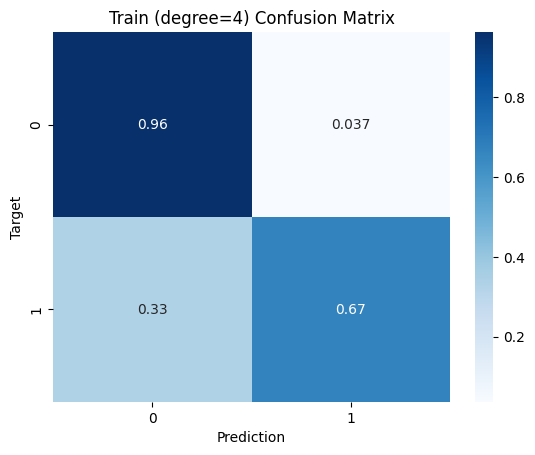

Area under ROC score on Validation (degree=4) dataset: 0.9301
F1 score on Validation (degree=4) dataset: 0.7216


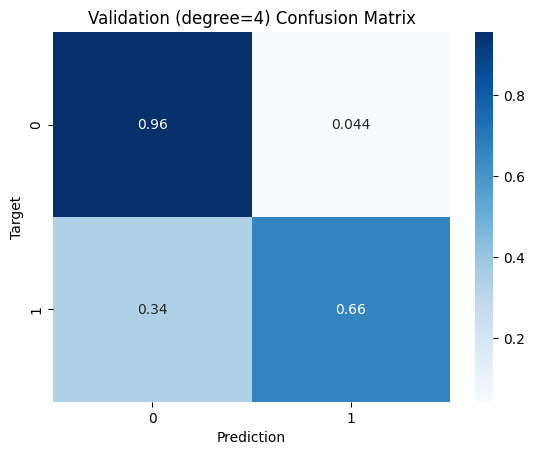

In [7]:
# Числовий трансформер з поліноміальними ознаками до степені 4
numeric_transformer_poly4 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=4))
])

preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_poly4.fit(train_inputs, train_targets)

print('Кількість ознак після препроцесингу:',
      model_pipeline_poly4.named_steps['preprocessor'].transform(train_inputs).shape[1])
print()
train_preds_poly4 = predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, 'Train (degree=4)')
val_preds_poly4 = predict_and_plot(model_pipeline_poly4, val_inputs, val_targets, 'Validation (degree=4)')

### Висновки до завдання 3

Створено третій пайплайн з `PolynomialFeatures(degree=4)`. Кількість ознак зросла до **500** — майже вдесятеро більше, ніж при degree=2.

**Модель знову покращилась, і перенавчання не спостерігається.** Розрив між train і val становить 0.003 за ROC-AUC (0.9331 проти 0.9301) — практично той самий, що й у попередніх моделях. Recall для класу 1 досяг 66%: модель знаходить дві третини клієнтів, які реально йдуть з банку, проти 56% у стартовій версії.

**Приріст якості суттєво вповільнився.** Перехід від degree=1 до degree=2 дав +0.039 ROC-AUC ціною 37 додаткових ознак. Перехід від degree=2 до degree=4 дав лише +0.011 ціною ще 450 ознак. Це спадна віддача: кожна наступна порція складності дає менше якості, зате збільшує час навчання та ускладнює інтерпретацію моделі.


In [8]:
test_raw_df = pd.read_csv('test.csv')

# Пайплайн сам зробить весь препроцесинг
test_probs = model_pipeline_poly4.predict_proba(test_raw_df[input_cols])[:, 1]

submission_df = pd.DataFrame({'id': test_raw_df['id'], 'Exited': test_probs})

print('submission_df.shape :', submission_df.shape)
print('Середня прогнозована ймовірність:', submission_df.Exited.mean().round(4))
display(submission_df.head())

# Save without row indices!
submission_df.to_csv('submission_poly4.csv', index=False)
print('\nФайл збережено:', 'submission_poly4.csv' in os.listdir('.'))

submission_df.shape : (10000, 2)
Середня прогнозована ймовірність: 0.211


,id,Exited
0,15000,0.078639
1,15001,0.020255
2,15002,0.070182
3,15003,0.397929
4,15004,0.025497



Файл збережено: True


**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [9]:
reg_df = pd.read_csv('regression_data.csv')

print('reg_df.shape :', reg_df.shape)
print()
reg_df.info()
print()
display(reg_df.head())

reg_df.shape : (129, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  129 non-null    float64
 1   feature_2  129 non-null    float64
 2   feature_3  129 non-null    float64
 3   feature_4  129 non-null    float64
 4   feature_5  129 non-null    float64
 5   target     129 non-null    float64
dtypes: float64(6)
memory usage: 6.2 KB



,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Helper for RMSE (squared=False is removed in new sklearn versions)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

X = reg_df.drop(columns=['target'])
y = reg_df['target']

# Розбивка на тренувальні та тест. дані
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly5_pipeline = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=5)),
    ('regressor', LinearRegression())
])

poly5_pipeline.fit(X_train, y_train)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Кількість ознак після PolynomialFeatures:',
      poly5_pipeline.named_steps['poly'].transform(
          poly5_pipeline.named_steps['scaler'].transform(X_train)).shape[1])
print()
print('Train RMSE: ', rmse(y_train, poly5_pipeline.predict(X_train)).round(4))
print('Test RMSE: ', rmse(y_test, poly5_pipeline.predict(X_test)).round(4))

X_train: (103, 5) | X_test: (26, 5)
Кількість ознак після PolynomialFeatures: 252

Train RMSE:  0.0
Test RMSE:  17.3488


### Висновки до завдання 4

Набір даних `regression_data.csv` містить лише **129 рядків** і 5 числових ознак. Після розбиття 80/20 у тренувальній вибірці залишилось 103 рядки. `PolynomialFeatures(degree=5)` згенерував з 5 ознак **252 ознаки**.


**Модель перенавчена.** Train RMSE дорівнює нулю — модель відтворює кожен тренувальний приклад абсолютно точно, без жодної похибки. При цьому на тестових даних помилка становить 17.35, що для цільової змінної з таким масштабом є дуже великою величиною.

 Модель не вивчила закономірність - вона **запам'ятала дані**. Це вже не апроксимація, а інтерполяція.

**Модель не генералізує взагалі.** Нульова помилка на тренуванні при великій помилці на тесті - це overfitting.

**Головний висновок:** небезпечна не сама кількість ознак, а її **співвідношення з кількістю прикладів**. Одна й та сама степінь полінома може бути корисною на великому наборі даних і шкідливою на малому.


**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [12]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

poly20 = PolynomialFeatures(degree=20)
X_train_scaled = MinMaxScaler().fit_transform(X_train)
X_train_poly20 = poly20.fit_transform(X_train_scaled)

print('Кількість тренувальних рядків:', X_train_poly20.shape[0])
print('Кількість ознак після PolynomialFeatures(degree=20):', X_train_poly20.shape[1])
print('Ознак на один приклад:', round(X_train_poly20.shape[1] / X_train_poly20.shape[0], 1))

Кількість тренувальних рядків: 103
Кількість ознак після PolynomialFeatures(degree=20): 53130
Ознак на один приклад: 515.8


In [13]:
def evaluate_model(model, X_train, y_train, X_val, y_val):
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_metrics = rmse(y_train, y_train_pred).round(4)
    val_metrics = rmse(y_val, y_val_pred).round(4)

    return dict(train=train_metrics, val=val_metrics)

scaler_20 = MinMaxScaler().fit(X_train)
poly_features_20 = PolynomialFeatures(degree=20)

X_train_poly = poly_features_20.fit_transform(scaler_20.transform(X_train))
X_test_poly = poly_features_20.transform(scaler_20.transform(X_test))

models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    ElasticNet()
]

for model in models:
    model.fit(X_train_poly, y_train)
    eval_results = evaluate_model(model, X_train_poly, y_train, X_test_poly, y_test)
    print(f'{str(model)}: {eval_results}\n')

LinearRegression(): {'train': np.float64(0.0), 'val': np.float64(12.7342)}

Ridge(): {'train': np.float64(5.8851), 'val': np.float64(7.0211)}

Lasso(): {'train': np.float64(5.0982), 'val': np.float64(5.6719)}

ElasticNet(): {'train': np.float64(30.0345), 'val': np.float64(30.4424)}



In [14]:
# Аналіз ознак: скільки коефіцієнтів реально використовує кожна модель
for model in models:
    coefs = model.coef_.flatten()
    n_nonzero = np.sum(np.abs(coefs) > 1e-6)
    print(f'{str(model)}:')
    print(f'  Ненульових коефіцієнтів: {n_nonzero} з {len(coefs)}')
    print(f'  Максимальна вага за модулем: {np.abs(coefs).max():.2f}')
    print(f'  Сума модулів ваг: {np.abs(coefs).sum():.2f}\n')

LinearRegression():
  Ненульових коефіцієнтів: 53128 з 53130
  Максимальна вага за модулем: 162.90
  Сума модулів ваг: 48057.15

Ridge():
  Ненульових коефіцієнтів: 53123 з 53130
  Максимальна вага за модулем: 54.87
  Сума модулів ваг: 2420.02

Lasso():
  Ненульових коефіцієнтів: 1 з 53130
  Максимальна вага за модулем: 194.93
  Сума модулів ваг: 194.93

ElasticNet():
  Ненульових коефіцієнтів: 162 з 53130
  Максимальна вага за модулем: 10.69
  Сума модулів ваг: 175.01



### Висновки до завдання 5

На тих самих даних (103 тренувальні рядки) згенеровано поліноміальні ознаки до степені 20 — це **53 130 ознак**, тобто 516 ознак на кожен приклад. Порівняно чотири моделі.

**Найкраще генералізує Lasso** — Test RMSE 5.67, що більш ніж удвічі краще за звичайну лінійну регресію (12.73), при найменшому розриві між train і test.

L1-регуляризація має унікальну властивість: вона **повністю обнуляє** ваги нерелевантних ознак, тобто виконує автоматичний відбір ознак. З 53 130 згенерованих комбінацій Lasso залишила **лише одну** — і цього виявилось достатньо для найкращого результату. Це означає, що в даних є одна домінуюча залежність, а решта 53 129 поліноміальних комбінацій — чистий шум.

**Ridge**  L2-регуляризація лише **стискає** ваги, але не обнуляє їх. Ridge зменшив суму модулів ваг з 48 057 до 2 420 (у 20 разів), однак усі 53 123 шумові ознаки залишились у моделі з малими, але ненульовими коефіцієнтами. Разом вони вносять помітну похибку на нових даних.

**LinearRegression** Сума модулів ваг 48 057 і максимальна вага 162.9 — модель використовує величезні коефіцієнти, які взаємно компенсуються, аби крива пройшла рівно через кожну тренувальну точку. Train RMSE = 0.0 означає повне запам'ятовування даних без будь-якого узагальнення.

**ElasticNet недонавчений** Тут помилка велика **однаково на train і на test** (30.03 та 30.44) — модель провалилась навіть на тих даних, які бачила під час навчання.
